In [8]:
import spotipy
import os
from spotipy.oauth2 import SpotifyClientCredentials
from spotipy.oauth2 import SpotifyOAuth
from pprint import pprint
import pandas as pd
from dotenv import load_dotenv
import random
from html import unescape
from IPython.display import clear_output

from matplotlib.ticker import MaxNLocator
import matplotlib.pyplot as plt

In [2]:
'''
dotenv file should contain:
SPOTIPY_CLIENT_ID = "your client id"
SPOTIPY_CLIENT_SECRET = "your client secret"  
SPOTIPY_REDIRECT_URI = "http://localhost:8888/callback"
'''
load_dotenv("C:/apis/.env") # path to your dotenv file
client_id = os.getenv("SPOTIPY_CLIENT_ID")
client_secret = os.getenv("SPOTIPY_CLIENT_SECRET")
redirect_uri = os.getenv("SPOTIPY_REDIRECT_URI")

# This masks your secret keys before printing them, in case you are sharing this notebook:
def mask_secret(unmasked_chars, secret):
    masked_token = secret[:unmasked_chars] + '*' * (len(secret) - unmasked_chars*2) + secret[-unmasked_chars:]
    return masked_token

print(f"SPOTIPY_CLIENT_ID: {mask_secret(4, client_id)}")
print(f"SPOTIPY_CLIENT_SECRET: {mask_secret(4, client_secret)}")
print(f"SPOTIPY_REDIRECT_URI: {redirect_uri}")

#sp = spotipy.Spotify(client_credentials_manager=SpotifyClientCredentials())
sp = spotipy.Spotify(auth_manager=SpotifyOAuth(client_id=os.getenv("SPOTIPY_CLIENT_ID"),
                                               client_secret=os.getenv("SPOTIPY_CLIENT_SECRET"),
                                               redirect_uri=os.getenv("SPOTIPY_REDIRECT_URI"),
                                               scope="playlist-modify-public playlist-modify-private"))

print(sp)
try:
    profile = sp.me()
except spotipy.exceptions.SpotifyException as exc:
    print(f"Unable to retrieve profile: {exc}")
else:
    print(f"Authenticated Spotify user: {profile.get('display_name') or profile.get('id')}")
    print(f"User ID: {profile.get('id')}")
    followers = profile.get('followers', {}).get('total')
    if followers is not None:
        print(f"Followers: {followers}")

SPOTIPY_CLIENT_ID: 3068************************2505
SPOTIPY_CLIENT_SECRET: 9945************************2daa
SPOTIPY_REDIRECT_URI: http://localhost:8888/callback
Authenticated Spotify user: David G. R. | reddgr
User ID: duhbeed
Followers: 60


## Gathering all playlists

Checking all my playlists:

In [ ]:
# user_id = profile.get('id') # using the same id as the authenticated user
user_id = "duhbeed"

try:
    results = sp.user_playlists(user_id)
except spotipy.exceptions.SpotifyException as exc:
    print(f"Failed to fetch playlists: {exc}")
else:
    if not results["items"]:
        print("No public playlists found.")
    else:
        while True:
            for playlist in results["items"]:
                print(f"{playlist['name']} ({playlist['tracks']['total']} tracks)")
            if results["next"]:
                results = sp.next(results)
            else:
                break

⌛ Mad Cool 2025 - Jueves (orden horario) ⌛ (100 tracks)
My 2024 Playlist in a Bottle (8 tracks)
Best of 2024 (2/3) | Electronic & Hip-Hop (18 tracks)
Best of 2024 (1/3) | (Mostly) Rock (17 tracks)
Lo Mejor de 2024 (3/3) | de España y/o en castellano (15 tracks)
Dogs of TikTok, YouTube and Instagram (reddgr.com) - sorted by track popularity (43 tracks)
Low Festival 2024  (Sábado) 🌊 ¡Orden horario! ⏰ (100 tracks)
Low Festival 2024 🌊 (Domingo) ¡Orden horario! ⏰ (Domingo) (100 tracks)
Low Festival 2024 🌊 ¡Orden horario! ⏰ (Viernes) (100 tracks)
Talking to Chatbots (Reddgr) (International Playlist) (20 tracks)
Colección de podcasts de Reddgr (17 tracks)
Tomavistas 2024 (orden horario) (146 tracks)
Bands and Artists I've Seen Live (Sorted by artist popularity)  (478 tracks)
Reddgr Curated Podcasts (35 tracks)
Dogs of TikTok, YouTube and Instagram (reddgr.com) (44 tracks)
Talking to Chatbots (TTCB) (15 tracks)
DCODE 2022 by David (112 tracks)
Mad Cool 2022 (Jueves) (121 tracks)
2022 (55 track

Full dataframe with playlist metadata:

In [ ]:
playlist_items = []
page = sp.user_playlists(user_id, limit=50)
while page:
    playlist_items.extend(page.get("items", []))
    page = sp.next(page) if page.get("next") else None

column_map = {
    "name": "name",
    "tracks.total": "tracks_total",
    "description": "description",
    "id": "playlist_id",
    "snapshot_id": "snapshot_id",
    "external_urls.spotify": "external_url",
    "uri": "uri",
    "primary_color": "primary_color",
    "owner.display_name": "owner_display_name",
    "owner.id": "owner_id",
    "public": "public",
    "collaborative": "collaborative",
}

if playlist_items:
    playlists_raw = pd.json_normalize(playlist_items)
    available_cols = [col for col in column_map if col in playlists_raw.columns]
    playlists_df = (
        playlists_raw[available_cols]
        .rename(columns={col: column_map[col] for col in available_cols})
    )
    playlists_df = playlists_df[[column_map[col] for col in available_cols]]
else:
    playlists_df = pd.DataFrame(columns=list(column_map.values()))


playlists_df["description"] = playlists_df["description"].map(
    lambda value: unescape(value) if isinstance(value, str) else value
)

playlists_df.to_pickle("pkl/reddgr_playlists.pkl")
playlists_df.to_csv("csv/reddgr_playlists.csv", index=False)

display(playlists_df)

,name,tracks_total,description,playlist_id,snapshot_id,external_url,uri,primary_color,owner_display_name,owner_id,public,collaborative
0,⌛ Mad Cool 2025 - Jueves (orden horario) ⌛,100,100 pistas para preparar el primer día de Mad ...,0acg8XNM0LxaTeSan2U50T,AAAArqHP41rl5rCp+ib7PEnauUlV+gpj,https://open.spotify.com/playlist/0acg8XNM0Lxa...,spotify:playlist:0acg8XNM0LxaTeSan2U50T,None,David G. R. | reddgr,duhbeed,True,False
1,My 2024 Playlist in a Bottle,8,A musical time capsule from the past has been ...,1x5Tv4ITB7rq0OPcUB0NEo,AAAAA7aIkhTuCJ9n9Lq8DK1+XwUBCz3o,https://open.spotify.com/playlist/1x5Tv4ITB7rq...,spotify:playlist:1x5Tv4ITB7rq0OPcUB0NEo,None,David G. R. | reddgr,duhbeed,True,False
2,Best of 2024 (2/3) | Electronic & Hip-Hop,18,"Every year's curated playlists, to be listened...",2Bqun7K2S7cAksiUFCQTEm,AAAARHBDRPQyajXV3u4Km8mNKaKRCOoS,https://open.spotify.com/playlist/2Bqun7K2S7cA...,spotify:playlist:2Bqun7K2S7cAksiUFCQTEm,None,David G. R. | reddgr,duhbeed,True,False
3,Best of 2024 (1/3) | (Mostly) Rock,17,"Every year's curated playlists, to be listened...",4AA6jg6T0PbzkVJZKyI5X9,AAAAU5ugERkxM+m+7k0rQJpTmzXlWlaz,https://open.spotify.com/playlist/4AA6jg6T0Pbz...,spotify:playlist:4AA6jg6T0PbzkVJZKyI5X9,None,David G. R. | reddgr,duhbeed,True,False
4,Lo Mejor de 2024 (3/3) | de España y/o en cast...,15,Mi sesión de canciones en castellano y de arti...,1LyCSbuOeqglulGBKP8vSZ,AAAAVf8WUm9jTLDdOsdAdAumSdFK86qP,https://open.spotify.com/playlist/1LyCSbuOeqgl...,spotify:playlist:1LyCSbuOeqglulGBKP8vSZ,None,David G. R. | reddgr,duhbeed,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
148,Totally Random Playlist,20,,0AMHQuovdwMQ36DQip0UpQ,AAAAV/jDxNUkR+/zNbkrCdNguzd06UDz,https://open.spotify.com/playlist/0AMHQuovdwMQ...,spotify:playlist:0AMHQuovdwMQ36DQip0UpQ,None,David G. R. | reddgr,duhbeed,True,False
149,Video Games,10,,0RGDLwNwo4p80AZgms2ZsE,AAAAD9ZjUNOEJc/sSg+Naa7Cv6/oAZoJ,https://open.spotify.com/playlist/0RGDLwNwo4p8...,spotify:playlist:0RGDLwNwo4p80AZgms2ZsE,None,David G. R. | reddgr,duhbeed,True,False
150,Violence,11,,6AUxha1PnIg6mvvklt0j6n,AAAAD75grCTf+eBiHcDpAZ/bJTKw9g26,https://open.spotify.com/playlist/6AUxha1PnIg6...,spotify:playlist:6AUxha1PnIg6mvvklt0j6n,None,David G. R. | reddgr,duhbeed,True,False
151,Weezer 10,10,,0erlbFfIKEV4eMJEtKhuoV,AAAAHSKE24JOgaiS2tjbSwNI3FtEm/sr,https://open.spotify.com/playlist/0erlbFfIKEV4...,spotify:playlist:0erlbFfIKEV4eMJEtKhuoV,None,David G. R. | reddgr,duhbeed,True,False


In [10]:
playlists_df.sample(5)

,name,tracks_total,description,playlist_id,snapshot_id,external_url,uri,primary_color,owner_display_name,owner_id,public,collaborative
54,Best of 2017 (2/6) (Indie/Alternative),18,,7ehiBKzNQoxj7wtQNXmhad,AAAAi/XuiHzcFYHsyB3yEe56Ax7oypvy,https://open.spotify.com/playlist/7ehiBKzNQoxj...,spotify:playlist:7ehiBKzNQoxj7wtQNXmhad,None,David G. R. | reddgr,duhbeed,True,False
39,Best of 2019 (3/6),18,"My 100-song selection of every year, split int...",0TPuVun8RAJiw6MXRB4590,AAAAkXgbVM0LLPd7Yp+VloT6QVrZ/Q1G,https://open.spotify.com/playlist/0TPuVun8RAJi...,spotify:playlist:0TPuVun8RAJiw6MXRB4590,None,David G. R. | reddgr,duhbeed,True,False
87,SOS 4.8 2014,39,,1gJH0TrY1WQw7OQOMR88ZJ,AAAAYDMc4JX0CzgpeGF6FAK59rMKu7De,https://open.spotify.com/playlist/1gJH0TrY1WQw...,spotify:playlist:1gJH0TrY1WQw7OQOMR88ZJ,None,David G. R. | reddgr,duhbeed,True,False
75,Best of 2015 (2/6) (Alternative/Other),17,,6CsLdv6uzrhOZA6dFSWSat,AAAAbkdB+49xKTrBGcuP6wpL+7cm8TVX,https://open.spotify.com/playlist/6CsLdv6uzrhO...,spotify:playlist:6CsLdv6uzrhOZA6dFSWSat,None,David G. R. | reddgr,duhbeed,True,False
109,1985,23,,5x8JXqhNJhJdbDwUXXUgFE,AAAAPXR7ftY16J5GITf5DRoXShHAjj9U,https://open.spotify.com/playlist/5x8JXqhNJhJd...,spotify:playlist:5x8JXqhNJhJdbDwUXXUgFE,None,David G. R. | reddgr,duhbeed,True,False


## Best-of-year playlists

In [27]:
print(pd.to_datetime("today").normalize().strftime("%Y%m%d"))

20251201


In [28]:
playlists_df = pd.read_pickle("pkl/reddgr_playlists.pkl")
name_lower = playlists_df["name"].fillna("").str.lower().str.strip()
bestof_year_playlists_df = (
    playlists_df[
        name_lower.str.startswith(("best of", "lo mejor de"))
        & ~name_lower.str.contains("so far")
        & ~name_lower.str.contains("discarded")
        & ~name_lower.str.endswith(("2013", "2014", "2016")) ## These years have duplicate playlists (one with all songs, others by genre)
    ].reset_index(drop=True)
)

bestof_year_playlists_df = bestof_year_playlists_df.assign(
    year=pd.to_numeric(
        bestof_year_playlists_df["name"].str.extract(r"\b(2[0-9]{3})\b", expand=False),
        errors="coerce"
    )
)
main_cols = ["name", "year", "tracks_total", "description"]
cols = main_cols + [col for col in bestof_year_playlists_df.columns if col not in main_cols]
bestof_year_playlists_df = bestof_year_playlists_df[cols]

bestof_year_playlists_df = bestof_year_playlists_df.sort_values("year", ascending=True, na_position="last")
today_date = pd.to_datetime("today").normalize().strftime("%Y%m%d")
bestof_year_playlists_df.to_pickle(f"pkl/reddgr_bestof_year_playlists_{today_date}.pkl")
bestof_year_playlists_df.to_csv(f"csv/reddgr_bestof_year_playlists_{today_date}.csv", index=False)
display(bestof_year_playlists_df)

,name,year,tracks_total,description,playlist_id,snapshot_id,external_url,uri,primary_color,owner_display_name,owner_id,public,collaborative
19,Best of 2010,2010,102,,5iBmxKUnNKzEZoYXxHYC2r,AAABUvdiqXREh7R4u2TxzLIgINVccq2z,https://open.spotify.com/playlist/5iBmxKUnNKzE...,spotify:playlist:5iBmxKUnNKzEZoYXxHYC2r,None,David G. R. | reddgr,duhbeed,True,False
20,Best of 2011,2011,101,,2lMwz55DQSDpnNed34XFRa,AAACCO8tlBBDSkBWi+zh+FUIVowCy5pz,https://open.spotify.com/playlist/2lMwz55DQSDp...,spotify:playlist:2lMwz55DQSDpnNed34XFRa,None,David G. R. | reddgr,duhbeed,True,False
66,Best of 2012 (bonus tracks),2012,23,,4jVzmc44I1IfrvgB2gaCIV,AAABztHil5w7vv0K1kpcb/CTmBbaf6u/,https://open.spotify.com/playlist/4jVzmc44I1If...,spotify:playlist:4jVzmc44I1IfrvgB2gaCIV,None,David G. R. | reddgr,duhbeed,True,False
61,Best of 2012 (1/5) (indie rock/pop),2012,21,,5T4WOAdvZH59w9Y4vMvzhH,AAAAQxonMZ+EjxVCIxS5tu3crzxt2uEo,https://open.spotify.com/playlist/5T4WOAdvZH59...,spotify:playlist:5T4WOAdvZH59w9Y4vMvzhH,None,David G. R. | reddgr,duhbeed,True,False
65,Best of 2012 (5/5) (mainstream/hits),2012,20,,2CqlGYfntq3xDAlp48PU4V,AAAAOWggXCt96+PZbB1wye00Zpotti9B,https://open.spotify.com/playlist/2CqlGYfntq3x...,spotify:playlist:2CqlGYfntq3xDAlp48PU4V,None,David G. R. | reddgr,duhbeed,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,Best of 2023 (2/3),2023,18,"In this year's collection, I've selected 50 so...",4XOMosM5oObvrcQVFCamFj,AAAAN2HQJgGJ1y7a9q0OzXqWJ9a+kB5H,https://open.spotify.com/playlist/4XOMosM5oObv...,spotify:playlist:4XOMosM5oObvrcQVFCamFj,None,David G. R. | reddgr,duhbeed,True,False
3,Best of 2023 (1/3),2023,18,"In this year's collection, I've selected 50 so...",34wg9M1ElBgos2l6QGExCd,AAAAPCLp2VtHkE0rm+UTkhq9PEIEf1zL,https://open.spotify.com/playlist/34wg9M1ElBgo...,spotify:playlist:34wg9M1ElBgos2l6QGExCd,None,David G. R. | reddgr,duhbeed,True,False
2,Lo Mejor de 2024 (3/3) | de España y/o en cast...,2024,15,Mi sesión de canciones en castellano y de arti...,1LyCSbuOeqglulGBKP8vSZ,AAAAVf8WUm9jTLDdOsdAdAumSdFK86qP,https://open.spotify.com/playlist/1LyCSbuOeqgl...,spotify:playlist:1LyCSbuOeqglulGBKP8vSZ,None,David G. R. | reddgr,duhbeed,True,False
1,Best of 2024 (1/3) | (Mostly) Rock,2024,17,"Every year's curated playlists, to be listened...",4AA6jg6T0PbzkVJZKyI5X9,AAAAU5ugERkxM+m+7k0rQJpTmzXlWlaz,https://open.spotify.com/playlist/4AA6jg6T0Pbz...,spotify:playlist:4AA6jg6T0PbzkVJZKyI5X9,None,David G. R. | reddgr,duhbeed,True,False


## Working with playlists table

In [29]:
bestof_year_playlists_df = pd.read_pickle("pkl/reddgr_bestof_year_playlists_20251201.pkl")
display(bestof_year_playlists_df.head(3))
display(bestof_year_playlists_df.tail(3))

,name,year,tracks_total,description,playlist_id,snapshot_id,external_url,uri,primary_color,owner_display_name,owner_id,public,collaborative
19,Best of 2010,2010,102,,5iBmxKUnNKzEZoYXxHYC2r,AAABUvdiqXREh7R4u2TxzLIgINVccq2z,https://open.spotify.com/playlist/5iBmxKUnNKzE...,spotify:playlist:5iBmxKUnNKzEZoYXxHYC2r,None,David G. R. | reddgr,duhbeed,True,False
20,Best of 2011,2011,101,,2lMwz55DQSDpnNed34XFRa,AAACCO8tlBBDSkBWi+zh+FUIVowCy5pz,https://open.spotify.com/playlist/2lMwz55DQSDp...,spotify:playlist:2lMwz55DQSDpnNed34XFRa,None,David G. R. | reddgr,duhbeed,True,False
66,Best of 2012 (bonus tracks),2012,23,,4jVzmc44I1IfrvgB2gaCIV,AAABztHil5w7vv0K1kpcb/CTmBbaf6u/,https://open.spotify.com/playlist/4jVzmc44I1If...,spotify:playlist:4jVzmc44I1IfrvgB2gaCIV,None,David G. R. | reddgr,duhbeed,True,False


,name,year,tracks_total,description,playlist_id,snapshot_id,external_url,uri,primary_color,owner_display_name,owner_id,public,collaborative
2,Lo Mejor de 2024 (3/3) | de España y/o en cast...,2024,15,Mi sesión de canciones en castellano y de arti...,1LyCSbuOeqglulGBKP8vSZ,AAAAVf8WUm9jTLDdOsdAdAumSdFK86qP,https://open.spotify.com/playlist/1LyCSbuOeqgl...,spotify:playlist:1LyCSbuOeqglulGBKP8vSZ,None,David G. R. | reddgr,duhbeed,True,False
1,Best of 2024 (1/3) | (Mostly) Rock,2024,17,"Every year's curated playlists, to be listened...",4AA6jg6T0PbzkVJZKyI5X9,AAAAU5ugERkxM+m+7k0rQJpTmzXlWlaz,https://open.spotify.com/playlist/4AA6jg6T0Pbz...,spotify:playlist:4AA6jg6T0PbzkVJZKyI5X9,None,David G. R. | reddgr,duhbeed,True,False
0,Best of 2024 (2/3) | Electronic & Hip-Hop,2024,18,"Every year's curated playlists, to be listened...",2Bqun7K2S7cAksiUFCQTEm,AAAARHBDRPQyajXV3u4Km8mNKaKRCOoS,https://open.spotify.com/playlist/2Bqun7K2S7cA...,spotify:playlist:2Bqun7K2S7cAksiUFCQTEm,None,David G. R. | reddgr,duhbeed,True,False


Extract a playlist into a dataframe:

In [30]:
def get_playlist_df(playlist_id):
    tracks_data = []
    offset = 0
    position = 1
    def format_duration(ms):
        if ms is None:
            return None
        minutes, seconds = divmod(int(ms) // 1000, 60)
        return f"{minutes}:{seconds:02d}"
    while True:
        response = sp.playlist_items(playlist_id, offset=offset, limit=100)
        items = response.get("items", [])
        if not items:
            break
        for item in items:
            track = item.get("track")
            if not track or track.get("type") != "track":
                continue
            album = track.get("album") or {}
            tracks_data.append({
                "position": position,
                "artists": ", ".join(artist.get("name") for artist in track.get("artists", [])),
                "track_name": track.get("name"),
                "album_name": album.get("name"),
                "release_date": album.get("release_date"),
                "track_popularity": track.get("popularity"),
                "duration_ms": track.get("duration_ms"),
                "added_at": item.get("added_at"),         
                "duration_mmss": format_duration(track.get("duration_ms")),           
                "external_url": (track.get("external_urls") or {}).get("spotify"),
                "track_id": track.get("id"),
                "track_uri": track.get("uri"),
            })
            position += 1
        offset += len(items)
        if not response.get("next"):
            break

    if tracks_data:
        playlist_tracks_df = pd.DataFrame(tracks_data)
        playlist_tracks_df["release_date"] = pd.to_datetime(playlist_tracks_df["release_date"], errors="coerce")
        playlist_tracks_df["added_at"] = pd.to_datetime(playlist_tracks_df["added_at"], errors="coerce")
    else:
        playlist_tracks_df = pd.DataFrame(columns=[
            "position", "track_id", "track_uri", "track_name", "artists", "album_name",
            "release_date", "added_at", "duration_ms", "duration_mmss", "track_popularity", "external_url"
        ])
    return playlist_tracks_df


# Random example
target_playlist = bestof_year_playlists_df.iloc[random.randint(0, len(bestof_year_playlists_df) - 1)]
playlist_id = target_playlist["playlist_id"]
playlist_tracks_df = get_playlist_df(playlist_id)
display(target_playlist[["name", "playlist_id", "tracks_total"]].to_frame().T)
display(playlist_tracks_df)

,name,playlist_id,tracks_total
58,Best of 2013 (4/6) (electronic/hip-hop),2AEOd8DOnopAijhL85xEvZ,17


,position,artists,track_name,album_name,release_date,track_popularity,duration_ms,added_at,duration_mmss,external_url,track_id,track_uri
0,1,M.I.A.,Double Bubble Trouble,Matangi,2013-01-01,0,179240,2013-11-13 22:38:48+00:00,2:59,https://open.spotify.com/track/27G5YWxn6GvJdh5...,27G5YWxn6GvJdh5wka4XOb,spotify:track:27G5YWxn6GvJdh5wka4XOb
1,2,"Disclosure, AlunaGeorge",White Noise,White Noise,2013-01-01,0,340268,2013-10-20 20:40:39+00:00,5:40,https://open.spotify.com/track/7mMaJKkvMKUB4KP...,7mMaJKkvMKUB4KPtWjMQ8D,spotify:track:7mMaJKkvMKUB4KPtWjMQ8D
2,3,Little Boots,Shake,Nocturnes,2013-05-05,0,331893,2013-10-20 20:41:40+00:00,5:31,https://open.spotify.com/track/2JFQD18raAApVSR...,2JFQD18raAApVSRMsXUfJL,spotify:track:2JFQD18raAApVSRMsXUfJL
3,4,Pet Shop Boys,Bolshy,Electric,2013-07-15,0,344625,2013-10-20 20:39:59+00:00,5:44,https://open.spotify.com/track/7xsriUA7W6us2VQ...,7xsriUA7W6us2VQitVCPw6,spotify:track:7xsriUA7W6us2VQitVCPw6
4,5,College,Tempête magnétique,Heritage,2013-04-01,20,310934,2013-10-20 20:38:05+00:00,5:10,https://open.spotify.com/track/2wzA7jB7hAmByyo...,2wzA7jB7hAmByyoRY6SYZJ,spotify:track:2wzA7jB7hAmByyoRY6SYZJ
5,6,Kavinsky,Odd Look,OutRun,2013-01-01,46,289773,2013-11-16 18:48:40+00:00,4:49,https://open.spotify.com/track/3T1CEAG5ukgdqGv...,3T1CEAG5ukgdqGvQuXWzqI,spotify:track:3T1CEAG5ukgdqGvQuXWzqI
6,7,Soft Metals,Hourglass,Lenses,2013-07-16,0,205909,2013-12-23 22:56:44+00:00,3:25,https://open.spotify.com/track/0iMD6Nf2gNMXsLB...,0iMD6Nf2gNMXsLBwYqdobe,spotify:track:0iMD6Nf2gNMXsLBwYqdobe
7,8,Bonobo,Cirrus,The North Borders,2013-03-21,60,352246,2013-10-20 20:40:35+00:00,5:52,https://open.spotify.com/track/2lJ4d8MCT6ZlDRH...,2lJ4d8MCT6ZlDRHKJ1br14,spotify:track:2lJ4d8MCT6ZlDRHKJ1br14
8,9,DJ Koze,Nices Wölkchen (feat. Apparat),Amygdala,2013-03-22,0,331093,2013-11-30 18:11:11+00:00,5:31,https://open.spotify.com/track/3t7ubv3jEoV1twd...,3t7ubv3jEoV1twd5DJPwAJ,spotify:track:3t7ubv3jEoV1twd5DJPwAJ
9,10,The Range,Metal Swing,Nonfiction,2013-10-14,17,248104,2013-11-01 10:53:46+00:00,4:08,https://open.spotify.com/track/6MpxBzJJTSw6m6K...,6MpxBzJJTSw6m6K7HzHrVM,spotify:track:6MpxBzJJTSw6m6K7HzHrVM


In [31]:
all_playlist_frames = []
for _, playlist in bestof_year_playlists_df.iterrows():
    tracks_df = get_playlist_df(playlist["playlist_id"])
    print(f"Fetched {len(tracks_df)} tracks from playlist: {playlist['name']}")
    clear_output(wait=True)
    if tracks_df.empty:
        continue
    tracks_df = tracks_df.assign(
        playlist_id=playlist["playlist_id"],
        playlist_name=playlist["name"]
    )
    all_playlist_frames.append(tracks_df)

if all_playlist_frames:
    bestof_year_tracks_df = pd.concat(all_playlist_frames, ignore_index=True)
    ordered_columns = ["playlist_name", "playlist_id"] + [
        column for column in bestof_year_tracks_df.columns
        if column not in {"playlist_name", "playlist_id"}
    ]
    bestof_year_tracks_df = bestof_year_tracks_df[ordered_columns]
else:
    bestof_year_tracks_df = pd.DataFrame(
        columns=["playlist_name", "playlist_id"] + list(playlist_tracks_df.columns)
    )

display(bestof_year_tracks_df)

,playlist_name,playlist_id,position,artists,track_name,album_name,release_date,track_popularity,duration_ms,added_at,duration_mmss,external_url,track_id,track_uri
0,Best of 2010,5iBmxKUnNKzEZoYXxHYC2r,1,Arcade Fire,Ready To Start,The Suburbs,NaT,0,255000,2010-12-11 17:30:44+00:00,4:15,None,None,spotify:local:Arcade+Fire:The+Suburbs:Ready+To...
1,Best of 2010,5iBmxKUnNKzEZoYXxHYC2r,2,Beach House,Used To Be,Teen Dream,2010-01-25,0,238760,2010-06-18 17:52:50+00:00,3:58,https://open.spotify.com/track/6ucl3HxRJoVhaIt...,6ucl3HxRJoVhaItQ72hcR1,spotify:track:6ucl3HxRJoVhaItQ72hcR1
2,Best of 2010,5iBmxKUnNKzEZoYXxHYC2r,3,"Broken Bells, Danger Mouse, James Mercer",The High Road,Broken Bells,2010-03-01,63,232200,2010-06-18 17:59:47+00:00,3:52,https://open.spotify.com/track/5cwN1htZyoWqZCc...,5cwN1htZyoWqZCc33f3RfE,spotify:track:5cwN1htZyoWqZCc33f3RfE
3,Best of 2010,5iBmxKUnNKzEZoYXxHYC2r,4,Interpol,Lights,Interpol,2010-09-07,0,337693,2010-09-18 13:37:48+00:00,5:37,https://open.spotify.com/track/7vGwKYk7TjizRRL...,7vGwKYk7TjizRRLHlbJ3ye,spotify:track:7vGwKYk7TjizRRLHlbJ3ye
4,Best of 2010,5iBmxKUnNKzEZoYXxHYC2r,5,The Tallest Man On Earth,King of Spain,The Wild Hunt,2010-04-12,0,208200,2010-08-23 20:08:24+00:00,3:28,https://open.spotify.com/track/73nQzhgyvxkYosA...,73nQzhgyvxkYosAmTlcFm6,spotify:track:73nQzhgyvxkYosAmTlcFm6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1326,Best of 2024 (2/3) | Electronic & Hip-Hop,2Bqun7K2S7cAksiUFCQTEm,14,whenyoung,Rubiks Cube,Rubiks Cube,2023-02-23,0,190880,2024-12-25 22:57:43+00:00,3:10,https://open.spotify.com/track/1B2F3ItQzXPpa02...,1B2F3ItQzXPpa02K74JLBY,spotify:track:1B2F3ItQzXPpa02K74JLBY
1327,Best of 2024 (2/3) | Electronic & Hip-Hop,2Bqun7K2S7cAksiUFCQTEm,15,Elderbrook,Shallow Water,Another Touch,2024-10-25,57,202893,2024-12-25 18:06:42+00:00,3:22,https://open.spotify.com/track/0k94VnTgKqsqnlx...,0k94VnTgKqsqnlxj5HT4Wx,spotify:track:0k94VnTgKqsqnlxj5HT4Wx
1328,Best of 2024 (2/3) | Electronic & Hip-Hop,2Bqun7K2S7cAksiUFCQTEm,16,"Nick León, Erika de Casier",Bikini,Bikini,2024-07-26,40,185798,2024-12-25 23:12:12+00:00,3:05,https://open.spotify.com/track/7KZa2q92Dwbjrx2...,7KZa2q92Dwbjrx2zo4obgw,spotify:track:7KZa2q92Dwbjrx2zo4obgw
1329,Best of 2024 (2/3) | Electronic & Hip-Hop,2Bqun7K2S7cAksiUFCQTEm,17,James Blake,Like The End,Like The End,2024-11-13,41,319561,2024-12-25 17:23:49+00:00,5:19,https://open.spotify.com/track/08MCWw0tB5BAPKJ...,08MCWw0tB5BAPKJuSgQMqZ,spotify:track:08MCWw0tB5BAPKJuSgQMqZ


In [32]:
today_date = pd.to_datetime("today").normalize().strftime("%Y%m%d")
bestof_year_tracks_df.to_pickle(f"pkl/reddgr_bestof_year_tracks_{today_date}.pkl")
bestof_year_tracks_df.to_csv(f"csv/reddgr_bestof_year_tracks_{today_date}.csv", index=False)

In [33]:
bestof_year_tracks_df = pd.read_pickle("pkl/reddgr_bestof_year_tracks_20251201.pkl")
print(bestof_year_tracks_df.iloc[2].get("artists"))
print(bestof_year_tracks_df.iloc[3].get("artists"))

Broken Bells, Danger Mouse, James Mercer
Interpol


## Ranking by total artist appearances (including collaborations)

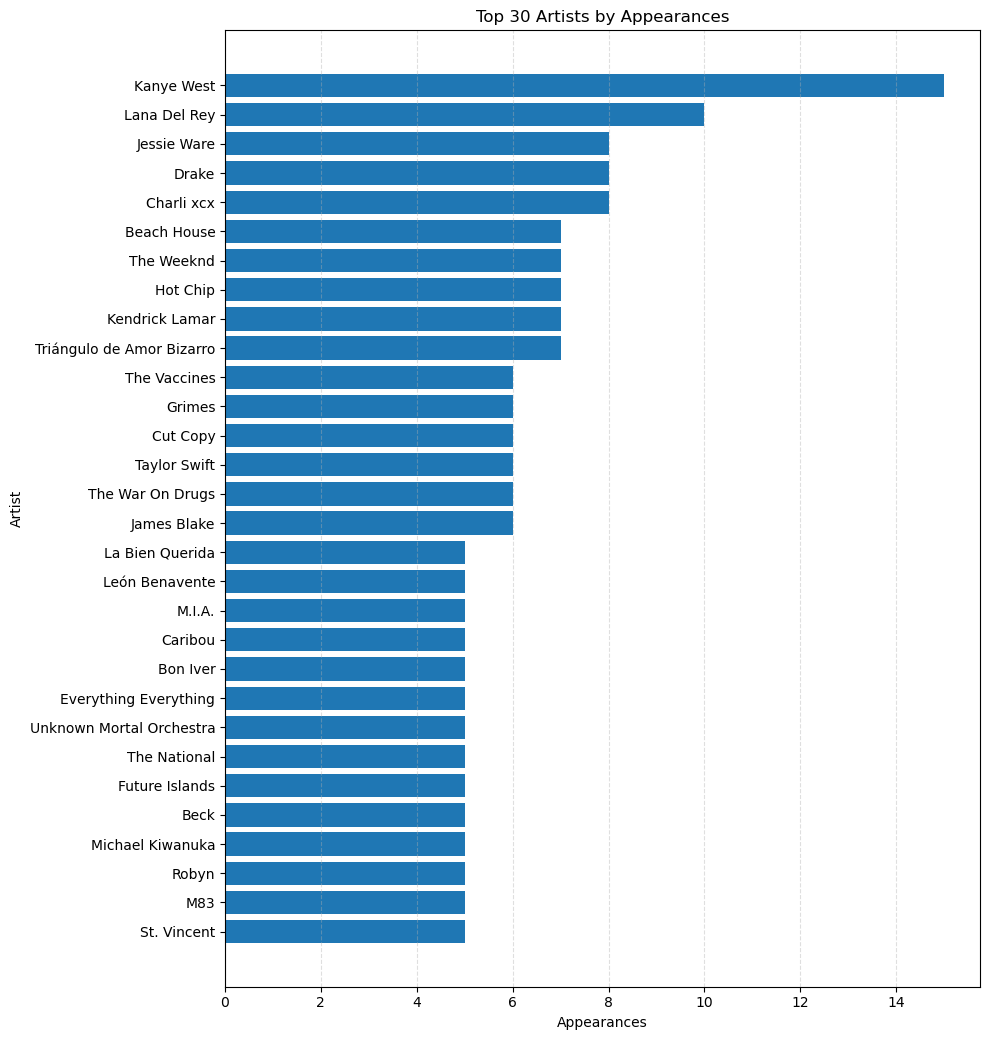

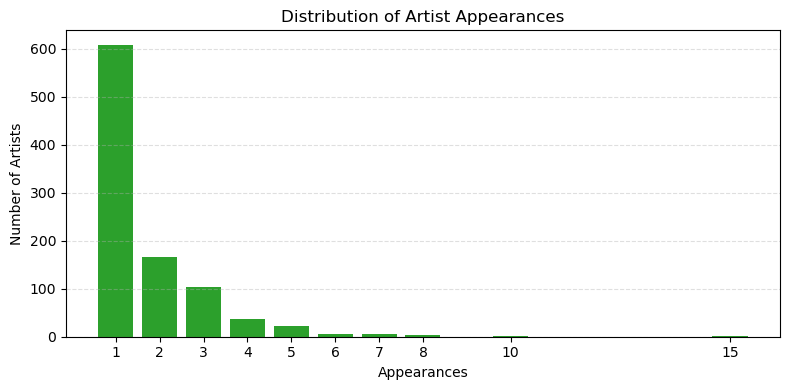

In [34]:
artists_series = (
    bestof_year_tracks_df["artists"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
    .replace("", pd.NA)
    .dropna()
)

artist_ranking_df = (
    artists_series.value_counts()
    .rename_axis("artist")
    .reset_index(name="appearances")
)

# display(artist_ranking_df.head(20))

top_n = 30
top_artists = artist_ranking_df.head(top_n).iloc[::-1]

fig, ax = plt.subplots(figsize=(10, max(6, top_n * 0.35)))
ax.barh(top_artists["artist"], top_artists["appearances"], color="tab:blue")
ax.set_xlabel("Appearances")
ax.set_ylabel("Artist")
ax.set_title(f"Top {top_n} Artists by Appearances")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

appearance_distribution = artist_ranking_df["appearances"].value_counts().sort_index()

fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.bar(appearance_distribution.index, appearance_distribution.values, color="tab:green")
ax2.set_xlabel("Appearances")
ax2.set_ylabel("Number of Artists")
ax2.set_title("Distribution of Artist Appearances")
ax2.set_xticks(appearance_distribution.index)
ax2.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [35]:
artist_ranking_df.head(15)

,artist,appearances
0,Kanye West,15
1,Lana Del Rey,10
2,Jessie Ware,8
3,Drake,8
4,Charli xcx,8
5,Beach House,7
6,The Weeknd,7
7,Hot Chip,7
8,Kendrick Lamar,7
9,Triángulo de Amor Bizarro,7


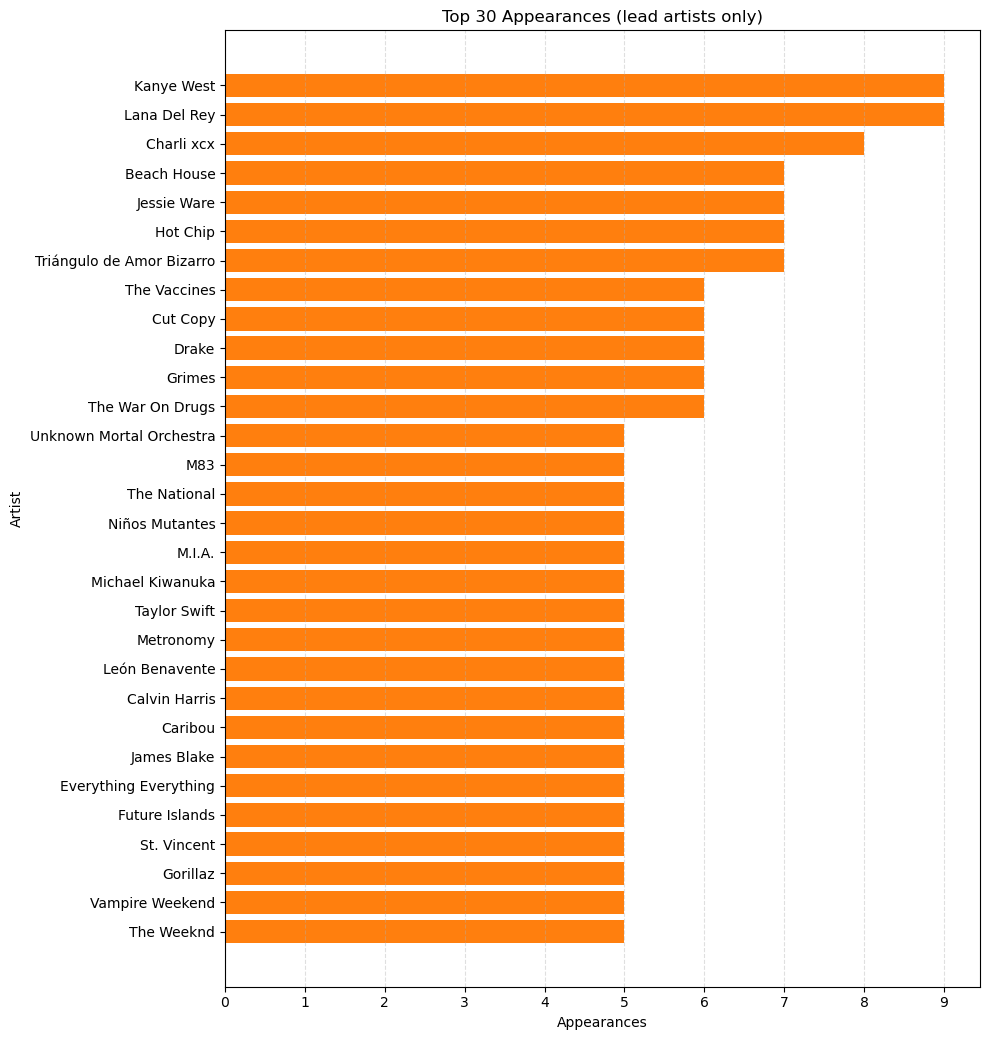

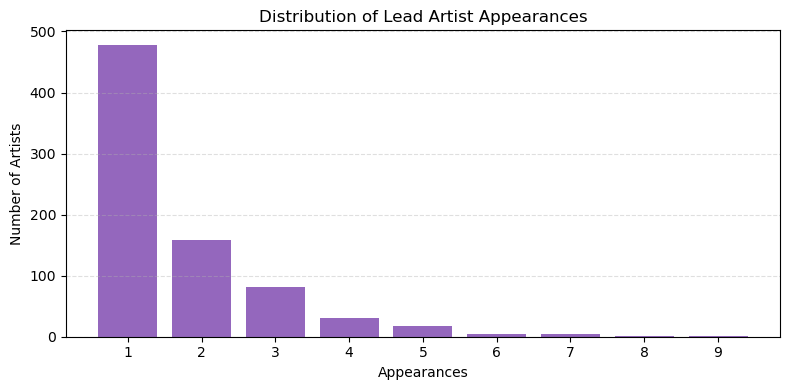

,artist,appearances
0,Kanye West,9
1,Lana Del Rey,9
2,Charli xcx,8
3,Beach House,7
4,Jessie Ware,7
5,Hot Chip,7
6,Triángulo de Amor Bizarro,7
7,The Vaccines,6
8,Cut Copy,6
9,Drake,6


In [36]:
lead_artists_series = (
    bestof_year_tracks_df["artists"]
    .dropna()
    .str.split(",", n=1)
    .str[0]
    .str.strip()
    .replace("", pd.NA)
    .dropna()
)

lead_artist_ranking_df = (
    lead_artists_series.value_counts()
    .rename_axis("artist")
    .reset_index(name="appearances")
)

lead_top_artists = lead_artist_ranking_df.head(top_n).iloc[::-1]

fig_lead, ax_lead = plt.subplots(figsize=(10, max(6, top_n * 0.35)))
ax_lead.barh(lead_top_artists["artist"], lead_top_artists["appearances"], color="tab:orange")
ax_lead.set_xlabel("Appearances")
ax_lead.set_ylabel("Artist")
ax_lead.set_title(f"Top {top_n} Appearances (lead artists only)")
ax_lead.xaxis.set_major_locator(MaxNLocator(integer=True))
ax_lead.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

lead_appearance_distribution = lead_artist_ranking_df["appearances"].value_counts().sort_index()

fig_lead2, ax_lead2 = plt.subplots(figsize=(8, 4))
ax_lead2.bar(lead_appearance_distribution.index, lead_appearance_distribution.values, color="tab:purple")
ax_lead2.set_xlabel("Appearances")
ax_lead2.set_ylabel("Number of Artists")
ax_lead2.set_title("Distribution of Lead Artist Appearances")
ax_lead2.set_xticks(lead_appearance_distribution.index)
ax_lead2.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

lead_artist_ranking_df.head(20)